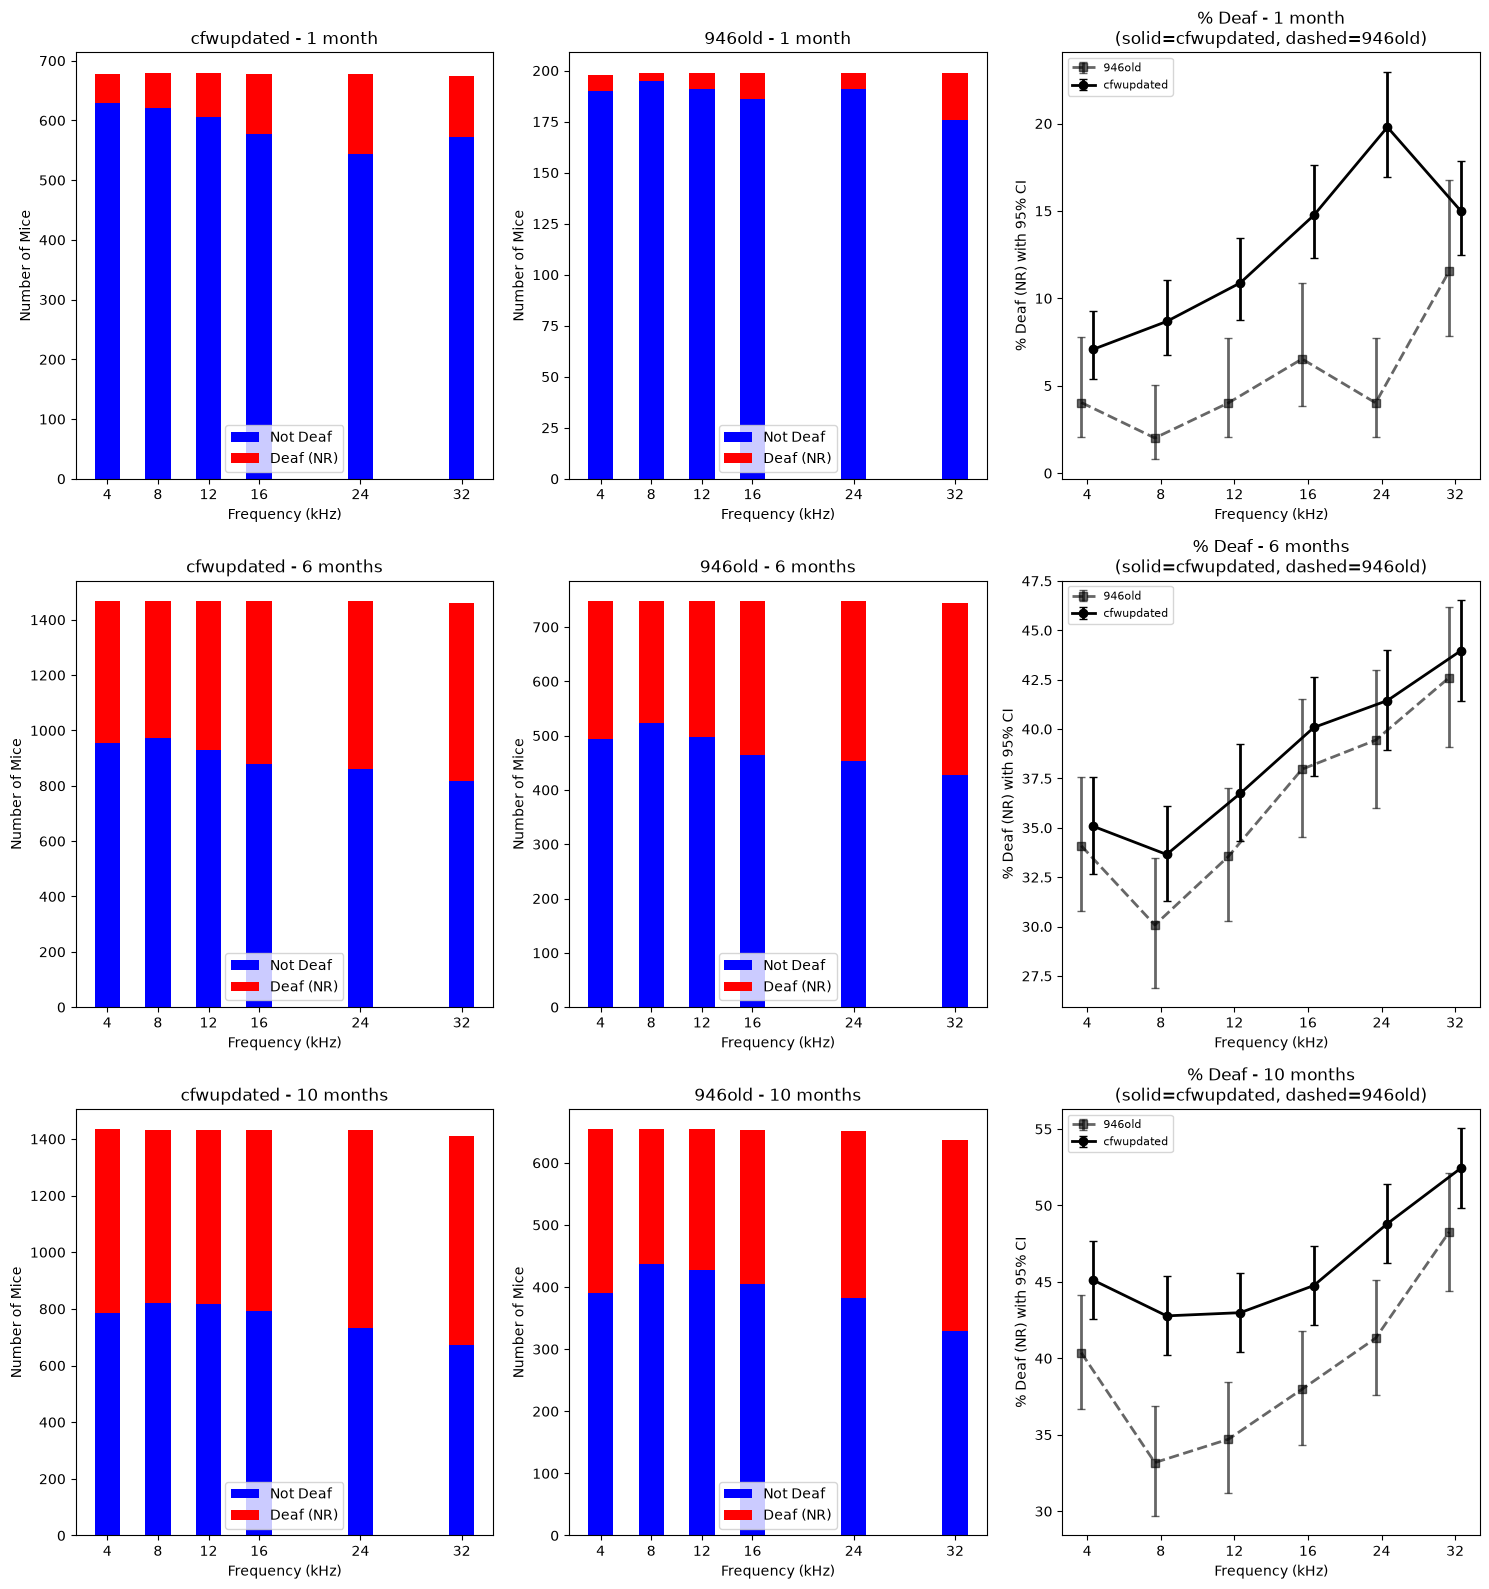

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('CFW.csv')
n946 = pd.read_csv("946idk.csv")

khz = [4, 8, 12, 16, 24, 32]
onemonth   = ['01mo_04_khz', '01mo_08_khz', '01mo_12_khz', '01mo_16_khz', '01mo_24_khz', '01mo_32_khz']
sixmonth   = ['06mo_04_khz', '06mo_08_khz', '06mo_12_khz', '06mo_16_khz', '06mo_24_khz', '06mo_32_khz']
tenmonths  = ['10mo_04_khz', '10mo_08_khz', '10mo_12_khz', '10mo_16_khz', '10mo_24_khz', '10mo_32_khz']

timepoints = {
    '1 month':   onemonth,
    '6 months':  sixmonth,
    '10 months': tenmonths,
}
datasets = {'cfwupdated': df, '946old': n946}


def wilson_ci(deaf, total, z=1.96):
    if total == 0:
        return np.nan, np.nan
    p = deaf / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    margin = (z * np.sqrt((p * (1 - p) / total) + (z**2 / (4 * total**2)))) / denom
    return center - margin, center + margin


def pct_with_ci(data, columns):
    pct, err_lo, err_hi = [], [], []
    for col in columns:
        valid_data = data[col].dropna()
        deaf = (valid_data == 'NR').sum()
        total = len(valid_data)
        if total == 0:
            pct.append(np.nan); err_lo.append(np.nan); err_hi.append(np.nan)
            continue
        p = deaf / total
        lo, hi = wilson_ci(deaf, total)
        pct.append(p * 100)
        err_lo.append(p * 100 - lo * 100)
        err_hi.append(hi * 100 - p * 100)
    return pct, err_lo, err_hi


x = np.arange(len(khz))
offset = 0.08

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 16))

for i, (time_title, columns) in enumerate(timepoints.items()):

    # ---- Column 0/1: stacked bar counts, same as before ----
    for j, (ds_name, data) in enumerate(datasets.items()):
        ax = axes[i][j]
        ax.set_title(f"{ds_name} - {time_title}")
        deaf_counts, not_deaf_counts = [], []
        for col in columns:
            valid_data = data[col].dropna()
            deaf = (valid_data == 'NR').sum()
            not_deaf = (valid_data != 'NR').sum()
            deaf_counts.append(deaf)
            not_deaf_counts.append(not_deaf)
        ax.bar(khz, not_deaf_counts, color='blue', label='Not Deaf', width=2)
        ax.bar(khz, deaf_counts, bottom=not_deaf_counts, color='red', label='Deaf (NR)', width=2)
        ax.set_xlabel('Frequency (kHz)')
        ax.set_ylabel('Number of Mice')
        ax.set_xticks(khz)
        ax.legend()

    # ---- Column 2: % deaf with 95% Wilson CI, old vs new overlaid ----
    ax = axes[i][2]
    pct_new, lo_new, hi_new = pct_with_ci(df, columns)
    pct_old, lo_old, hi_old = pct_with_ci(n946, columns)

    ax.errorbar(x - offset, pct_old, yerr=[lo_old, hi_old], color='black',
                marker='s', linestyle='--', alpha=0.6, linewidth=2,
                capsize=3, label='946old')
    ax.errorbar(x + offset, pct_new, yerr=[lo_new, hi_new], color='black',
                marker='o', linestyle='-', linewidth=2,
                capsize=3, label='cfwupdated')

    ax.set_xticks(x)
    ax.set_xticklabels(khz)
    ax.set_xlabel('Frequency (kHz)')
    ax.set_ylabel('% Deaf (NR) with 95% CI')
    ax.set_title(f"% Deaf - {time_title}\n(solid=cfwupdated, dashed=946old)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("grid_bars_plus_ci.png", dpi=150, bbox_inches='tight')
plt.show()

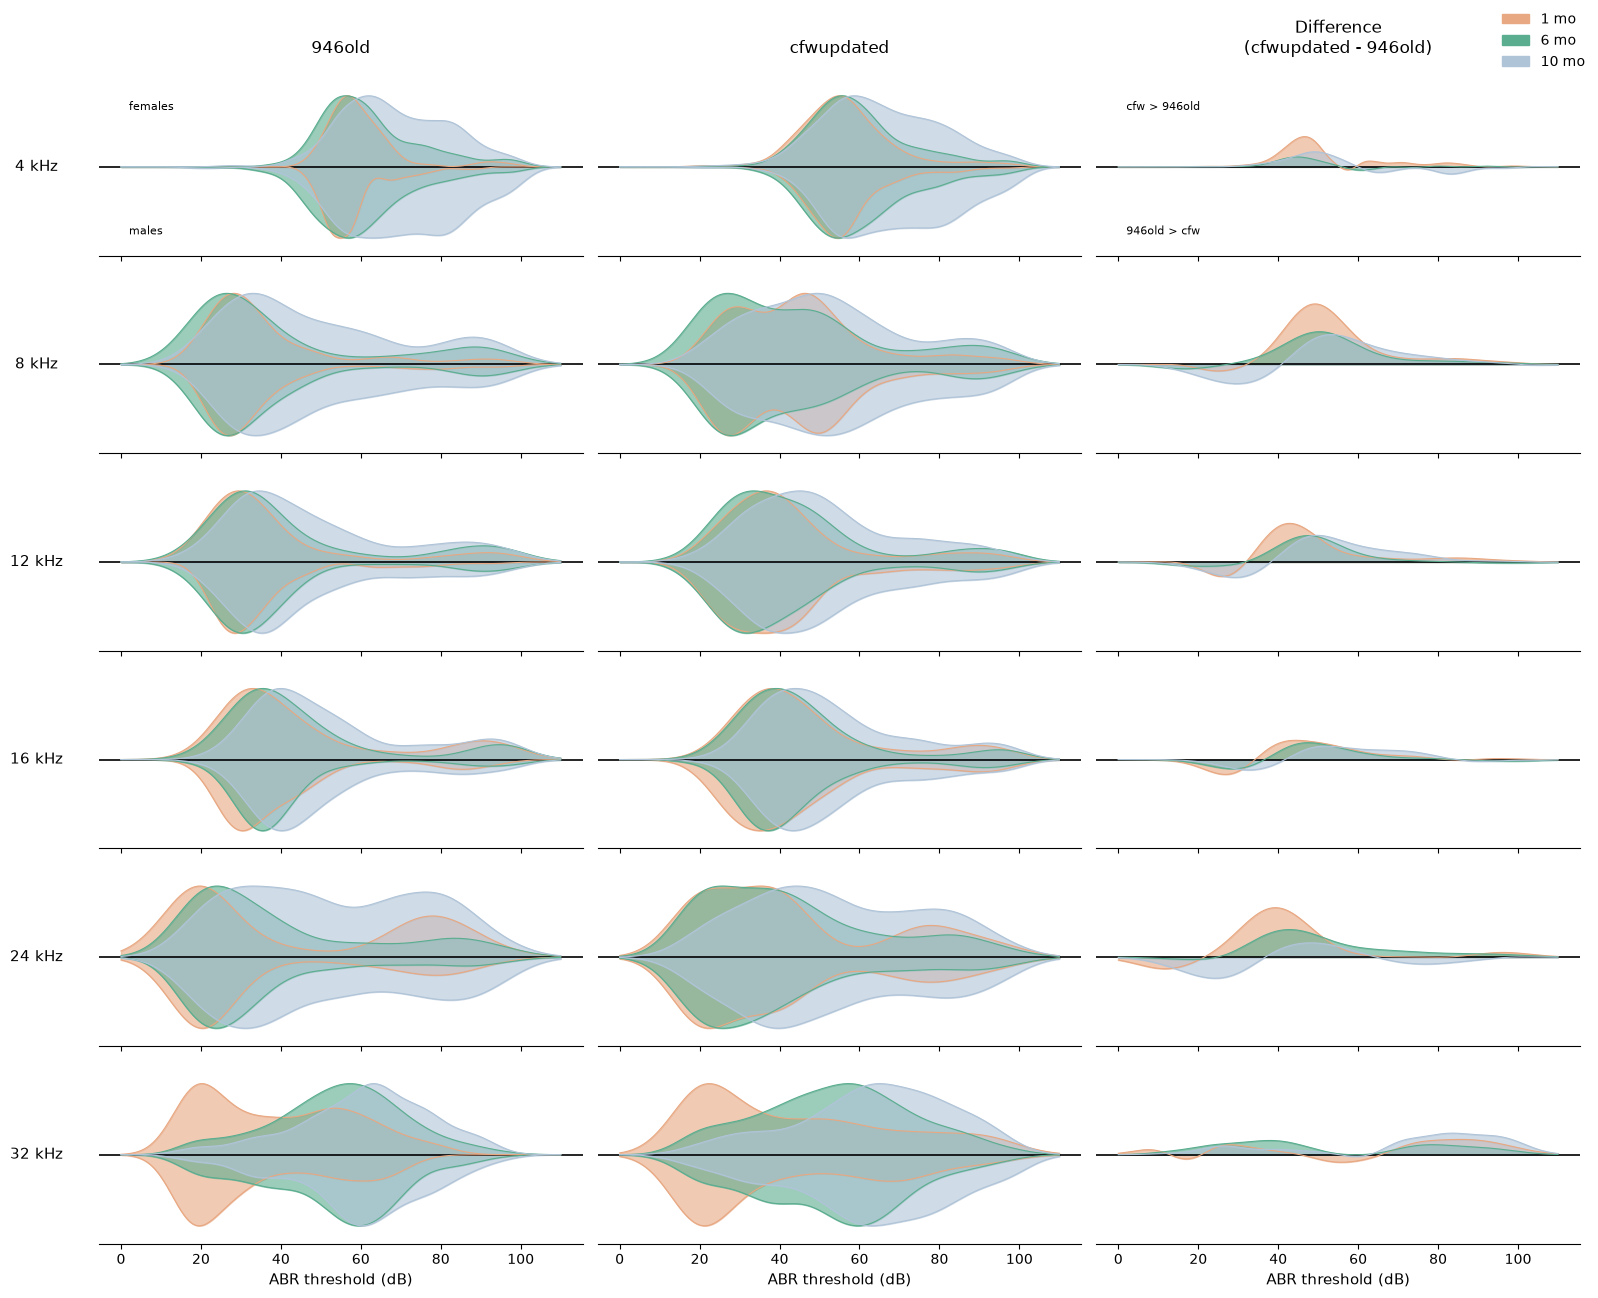

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

cfw = pd.read_csv("CFW.csv")
old946 = pd.read_csv("946idk.csv")

freqs = [4, 8, 12, 16, 24, 32]
ages = {
    '1 mo':  ['01mo_04_khz', '01mo_08_khz', '01mo_12_khz', '01mo_16_khz', '01mo_24_khz', '01mo_32_khz'],
    '6 mo':  ['06mo_04_khz', '06mo_08_khz', '06mo_12_khz', '06mo_16_khz', '06mo_24_khz', '06mo_32_khz'],
    '10 mo': ['10mo_04_khz', '10mo_08_khz', '10mo_12_khz', '10mo_16_khz', '10mo_24_khz', '10mo_32_khz'],
}
colors = {'1 mo': '#E8A882', '6 mo': '#5BAD8F', '10 mo': '#B0C4D8'}

x_range = np.linspace(0, 110, 300)


def get_values(df, col, sex=None):
    sub = df if sex is None else df[df['sex'] == sex]
    return pd.to_numeric(sub[col].replace('NR', np.nan), errors='coerce').dropna()


def norm_density(vals, bw=0.3):
        return None
    kde = gaussian_kde(vals, bw_method=bw)
    d = kde(x_range)
    return d / d.max()


# ── Figure: rows = frequencies, cols = [946old, cfwupdated, difference] ──
fig, axes = plt.subplots(len(freqs), 3, figsize=(16, 13), sharex=True)
fig.subplots_adjust(hspace=0.15)

col_titles = ['946old', 'cfwupdated', 'Difference\n(cfwupdated - 946old)']

for row, freq_idx in enumerate(range(len(freqs))):

    for col_idx, (dataset, dataset_name) in enumerate([(old946, '946old'), (cfw, 'cfwupdated')]):
        ax = axes[row][col_idx]
        ax.axhline(0, color='black', linewidth=1.2)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)

        for age_label, col_list in ages.items():
            col = col_list[freq_idx]
            color = colors[age_label]

            for sex, sign in [('F', 1), ('M', -1)]:
                vals = get_values(dataset, col, sex=sex)
                density = norm_density(vals)
                if density is None:
                    continue
                density = density * 0.4 * sign
                ax.fill_between(x_range, 0, density, alpha=0.6, color=color)
                ax.plot(x_range, density, color=color, linewidth=0.8)

        ax.set_ylim(-0.5, 0.5)
        if col_idx == 0:
            ax.set_ylabel(f'{freqs[freq_idx]} kHz', rotation=0, labelpad=45, va='center', fontsize=11)
        if row == 0:
            ax.set_title(dataset_name, fontsize=12, pad=18)
            if col_idx == 0:
                ax.text(2, 0.32, 'females', fontsize=8)
                ax.text(2, -0.38, 'males', fontsize=8)

    # ---------- Column 2: Difference (sexes combined, up = cfw higher density) -----
    ax = axes[row][2]
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left']].set_visible(False)

    for age_label, col_list in ages.items():
        col = col_list[freq_idx]
        color = colors[age_label]

        vals_cfw = get_values(cfw, col)
        vals_old = get_values(old946, col)
        d_cfw = norm_density(vals_cfw)
        d_old = norm_density(vals_old)
        if d_cfw is None or d_old is None:
            continue

        diff = (d_cfw - d_old) * 0.4
        ax.fill_between(x_range, 0, diff, alpha=0.6, color=color)
        ax.plot(x_range, diff, color=color, linewidth=0.8)

    ax.set_ylim(-0.5, 0.5)
    if row == 0:
        ax.set_title(col_titles[2], fontsize=12, pad=18)
        ax.text(2, 0.32, 'cfw > 946old', fontsize=8)
        ax.text(2, -0.38, '946old > cfw', fontsize=8)

# Shared legend + x-label
legend_patches = [plt.matplotlib.patches.Patch(color=colors[a], label=a) for a in ages]
for ax in axes[-1]:
    ax.set_xlabel('ABR threshold (dB)', fontsize=11)
fig.legend(handles=legend_patches, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("ridge_comparison_3col.png", dpi=150, bbox_inches='tight')
plt.show()

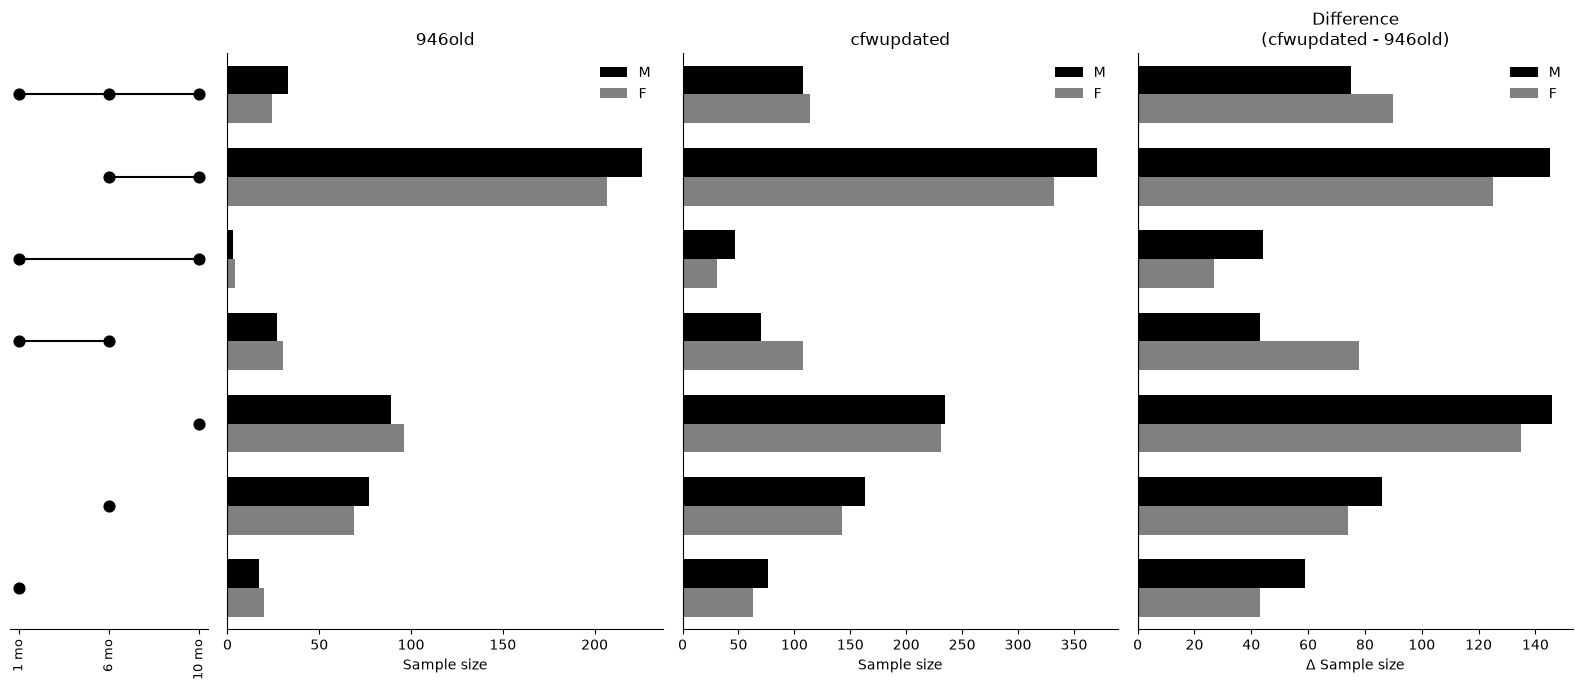

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

cfw = pd.read_csv("CFW.csv")
old946 = pd.read_csv("946idk.csv")

age_labels = ['1 mo', '6 mo', '10 mo']
timepoint_cols = {
    '1 mo':  '01mo_test_date',
    '6 mo':  '06mo_test_date',
    '10 mo': '10mo_test_date',
}


def combo_counts(df):
    """Return dict: combo(tuple) -> (m_count, f_count) for every possible
    timepoint combination, computed the same way for every dataset so rows
    line up across panels."""
    combos = []
    for r in range(1, len(age_labels) + 1):
        combos.extend(combinations(age_labels, r))

    out = {}
    for combo in combos:
        mask = pd.Series([True] * len(df), index=df.index)
        for age in combo:
            mask &= df[timepoint_cols[age]].notna()
        for age in age_labels:
            if age not in combo:
                mask &= df[timepoint_cols[age]].isna()
        sub = df[mask]
        m = (sub['sex'] == 'M').sum()
        f = (sub['sex'] == 'F').sum()
        out[combo] = (m, f)
    return out


old_counts = combo_counts(old946)
cfw_counts = combo_counts(cfw)

# keep only combos with data in at least one dataset, same order for every panel
all_combos = [c for c in old_counts if (old_counts[c][0] + old_counts[c][1]
                                         + cfw_counts[c][0] + cfw_counts[c][1]) > 0]

combo_m_old = [old_counts[c][0] for c in all_combos]
combo_f_old = [old_counts[c][1] for c in all_combos]
combo_m_cfw = [cfw_counts[c][0] for c in all_combos]
combo_f_cfw = [cfw_counts[c][1] for c in all_combos]
diff_m = [c - o for c, o in zip(combo_m_cfw, combo_m_old)]
diff_f = [c - o for c, o in zip(combo_f_cfw, combo_f_old)]

y_positions = np.arange(len(all_combos))
bar_h = 0.35

# ── Figure: dot panel + 3 bar panels (946old | cfwupdated | difference) ──
fig, axes = plt.subplots(
    1, 4, figsize=(16, 7),
    gridspec_kw={'width_ratios': [1, 2.2, 2.2, 2.2]}
)
ax_dot, ax_old, ax_new, ax_diff = axes

# Dot panel (shared reference for which timepoints make up each row)
dot_x = {age: i for i, age in enumerate(age_labels)}
for y, combo in enumerate(all_combos):
    xs = [dot_x[a] for a in combo]
    ys = [y] * len(xs)
    ax_dot.plot(xs, ys, 'k-', linewidth=1.5, zorder=1)
    ax_dot.scatter(xs, ys, color='black', s=60, zorder=2)

ax_dot.set_xticks(range(len(age_labels)))
ax_dot.set_xticklabels(age_labels, rotation=90, fontsize=9)
ax_dot.set_yticks([])
ax_dot.set_ylim(-0.5, len(all_combos) - 0.5)
ax_dot.spines[['top', 'right', 'left']].set_visible(False)

# 946old bar panel
ax_old.barh(y_positions + bar_h / 2, combo_m_old, height=bar_h, color='black', label='M')
ax_old.barh(y_positions - bar_h / 2, combo_f_old, height=bar_h, color='gray', label='F')
ax_old.set_title('946old', fontsize=12)
ax_old.set_xlabel('Sample size')
ax_old.set_yticks([])
ax_old.set_ylim(-0.5, len(all_combos) - 0.5)
ax_old.legend(frameon=False)
ax_old.spines[['top', 'right']].set_visible(False)

# cfwupdated bar panel
ax_new.barh(y_positions + bar_h / 2, combo_m_cfw, height=bar_h, color='black', label='M')
ax_new.barh(y_positions - bar_h / 2, combo_f_cfw, height=bar_h, color='gray', label='F')
ax_new.set_title('cfwupdated', fontsize=12)
ax_new.set_xlabel('Sample size')
ax_new.set_yticks([])
ax_new.set_ylim(-0.5, len(all_combos) - 0.5)
ax_new.legend(frameon=False)
ax_new.spines[['top', 'right']].set_visible(False)

# Difference bar panel (cfwupdated - 946old) — same black/gray M/F coloring
ax_diff.barh(y_positions + bar_h / 2, diff_m, height=bar_h, color='black', label='M')
ax_diff.barh(y_positions - bar_h / 2, diff_f, height=bar_h, color='gray', label='F')
ax_diff.axvline(0, color='black', linewidth=0.8)
ax_diff.set_title('Difference\n(cfwupdated - 946old)', fontsize=12)
ax_diff.set_xlabel('Δ Sample size')
ax_diff.set_yticks([])
ax_diff.set_ylim(-0.5, len(all_combos) - 0.5)
ax_diff.legend(frameon=False)
ax_diff.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("sample_size_3col.png", dpi=150, bbox_inches='tight')
plt.show()

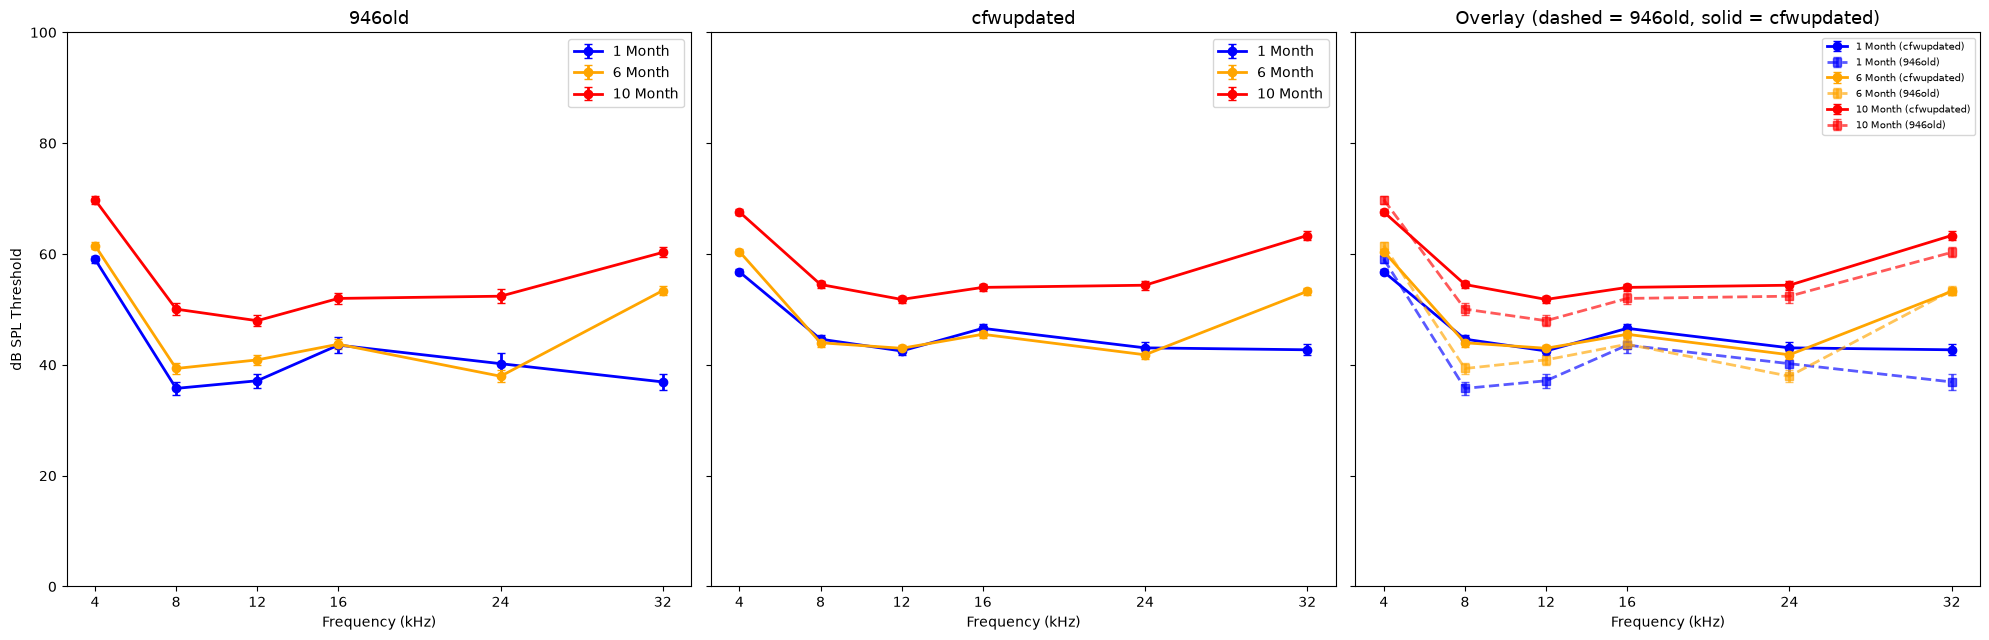

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cfw = pd.read_csv("CFW.csv")
old946 = pd.read_csv("946idk.csv")

freqs = [4, 8, 12, 16, 24, 32]
ages = {
    '1 Month':  ['01mo_04_khz', '01mo_08_khz', '01mo_12_khz', '01mo_16_khz', '01mo_24_khz', '01mo_32_khz'],
    '6 Month':  ['06mo_04_khz', '06mo_08_khz', '06mo_12_khz', '06mo_16_khz', '06mo_24_khz', '06mo_32_khz'],
    '10 Month': ['10mo_04_khz', '10mo_08_khz', '10mo_12_khz', '10mo_16_khz', '10mo_24_khz', '10mo_32_khz'],
}
colors = {'1 Month': 'blue', '6 Month': 'orange', '10 Month': 'red'}


def mean_sem(df, col):
    vals = pd.to_numeric(df[col].replace('NR', np.nan), errors='coerce').dropna()
    if len(vals) == 0:
        return np.nan, np.nan
    return vals.mean(), vals.sem()


def dataset_stats(df):
    out = {}
    for age_label, col_list in ages.items():
        means, sems = [], []
        for col in col_list:
            m, s = mean_sem(df, col)
            means.append(m)
            sems.append(s)
        out[age_label] = (np.array(means), np.array(sems))
    return out


old_stats = dataset_stats(old946)
cfw_stats = dataset_stats(cfw)

# ── Figure: 946old panel | cfwupdated panel | overlay panel ──
fig, (ax_old, ax_new, ax_overlay) = plt.subplots(1, 3, figsize=(20, 6.5), sharey=True)

# --- 946old panel ---
for age_label in ages:
    means, sems = old_stats[age_label]
    ax_old.errorbar(freqs, means, yerr=sems, color=colors[age_label], marker='o',
                     linewidth=2, capsize=3, label=age_label)
ax_old.set_title('946old', fontsize=13)
ax_old.set_xlabel('Frequency (kHz)')
ax_old.set_ylabel('dB SPL Threshold')
ax_old.set_xticks(freqs)
ax_old.set_ylim(0, 100)
ax_old.legend(frameon=True)

# --- cfwupdated panel ---
for age_label in ages:
    means, sems = cfw_stats[age_label]
    ax_new.errorbar(freqs, means, yerr=sems, color=colors[age_label], marker='o',
                     linewidth=2, capsize=3, label=age_label)
ax_new.set_title('cfwupdated', fontsize=13)
ax_new.set_xlabel('Frequency (kHz)')
ax_new.set_xticks(freqs)
ax_new.set_ylim(0, 100)
ax_new.legend(frameon=True)

# --- Overlay panel: solid = cfwupdated, dashed = 946old, same color per age ---
for age_label in ages:
    means_old, sems_old = old_stats[age_label]
    means_new, sems_new = cfw_stats[age_label]
    c = colors[age_label]

    ax_overlay.errorbar(freqs, means_new, yerr=sems_new, color=c, marker='o',
                         linewidth=2, linestyle='-', capsize=3,
                         label=f'{age_label} (cfwupdated)')
    ax_overlay.errorbar(freqs, means_old, yerr=sems_old, color=c, marker='s',
                         linewidth=2, linestyle='--', capsize=3, alpha=0.65,
                         label=f'{age_label} (946old)')

ax_overlay.set_title('Overlay (dashed = 946old, solid = cfwupdated)', fontsize=13)
ax_overlay.set_xlabel('Frequency (kHz)')
ax_overlay.set_xticks(freqs)
ax_overlay.set_ylim(0, 100)
ax_overlay.legend(frameon=True, fontsize=7.5, ncol=1, loc='upper right')

plt.tight_layout()
plt.savefig("line_sem_old_new_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

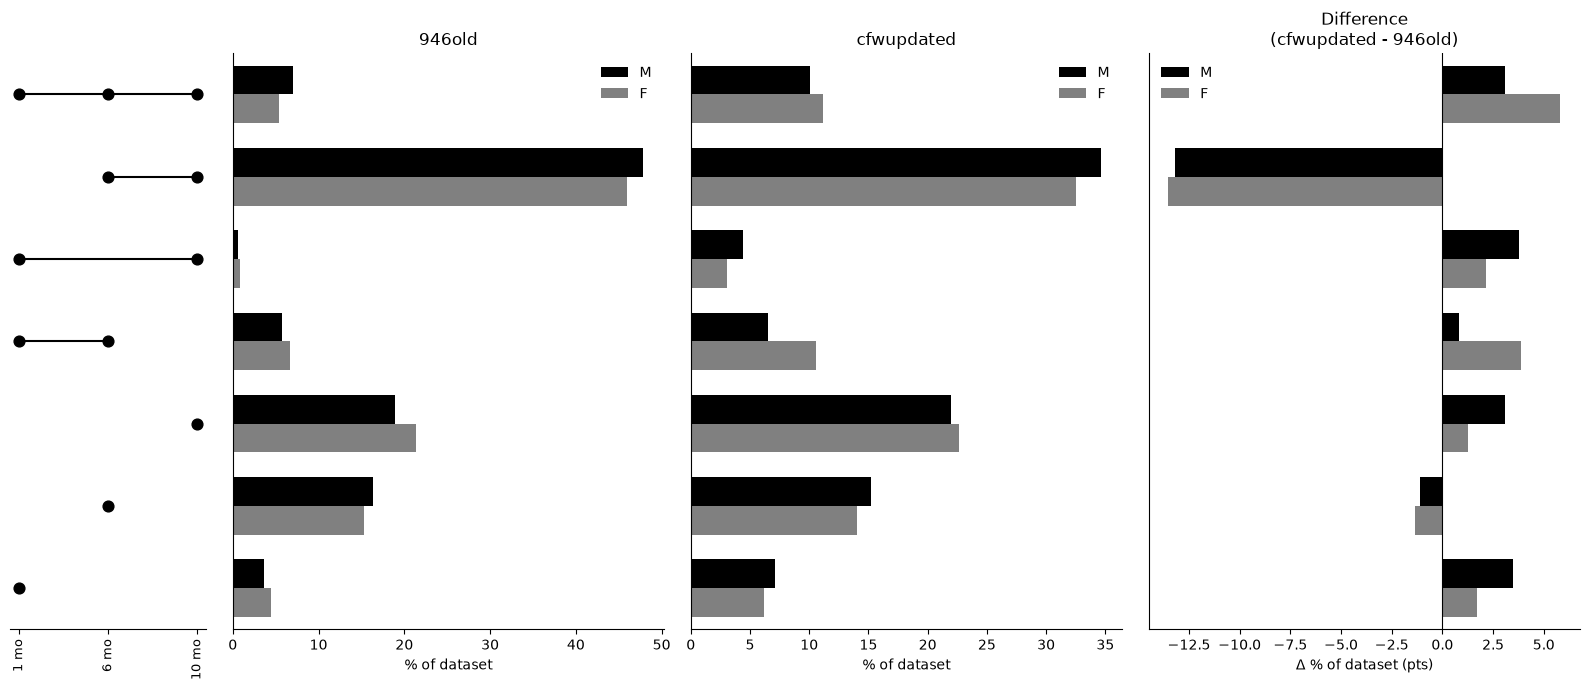

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

cfw = pd.read_csv("CFW.csv")
old946 = pd.read_csv("946idk.csv")

age_labels = ['1 mo', '6 mo', '10 mo']
timepoint_cols = {
    '1 mo':  '01mo_test_date',
    '6 mo':  '06mo_test_date',
    '10 mo': '10mo_test_date',
}


def combo_counts(df):
    combos = []
    for r in range(1, len(age_labels) + 1):
        combos.extend(combinations(age_labels, r))

    out = {}
    for combo in combos:
        mask = pd.Series([True] * len(df), index=df.index)
        for age in combo:
            mask &= df[timepoint_cols[age]].notna()
        for age in age_labels:
            if age not in combo:
                mask &= df[timepoint_cols[age]].isna()
        sub = df[mask]
        m = (sub['sex'] == 'M').sum()
        f = (sub['sex'] == 'F').sum()
        out[combo] = (m, f)
    return out


old_counts = combo_counts(old946)
cfw_counts = combo_counts(cfw)

# totals per sex per dataset, for converting to % of that dataset's mice
old_total_m = sum(v[0] for v in old_counts.values())
old_total_f = sum(v[1] for v in old_counts.values())
cfw_total_m = sum(v[0] for v in cfw_counts.values())
cfw_total_f = sum(v[1] for v in cfw_counts.values())

all_combos = [c for c in old_counts if (old_counts[c][0] + old_counts[c][1]
                                         + cfw_counts[c][0] + cfw_counts[c][1]) > 0]

# convert counts -> % of dataset's total M / total F
pct_m_old = [old_counts[c][0] / old_total_m * 100 for c in all_combos]
pct_f_old = [old_counts[c][1] / old_total_f * 100 for c in all_combos]
pct_m_new = [cfw_counts[c][0] / cfw_total_m * 100 for c in all_combos]
pct_f_new = [cfw_counts[c][1] / cfw_total_f * 100 for c in all_combos]
diff_m = [n - o for n, o in zip(pct_m_new, pct_m_old)]
diff_f = [n - o for n, o in zip(pct_f_new, pct_f_old)]

y_positions = np.arange(len(all_combos))
bar_h = 0.35

fig, axes = plt.subplots(
    1, 4, figsize=(16, 7),
    gridspec_kw={'width_ratios': [1, 2.2, 2.2, 2.2]}
)
ax_dot, ax_old, ax_new, ax_diff = axes

# Dot panel
dot_x = {age: i for i, age in enumerate(age_labels)}
for y, combo in enumerate(all_combos):
    xs = [dot_x[a] for a in combo]
    ys = [y] * len(xs)
    ax_dot.plot(xs, ys, 'k-', linewidth=1.5, zorder=1)
    ax_dot.scatter(xs, ys, color='black', s=60, zorder=2)
ax_dot.set_xticks(range(len(age_labels)))
ax_dot.set_xticklabels(age_labels, rotation=90, fontsize=9)
ax_dot.set_yticks([])
ax_dot.set_ylim(-0.5, len(all_combos) - 0.5)
ax_dot.spines[['top', 'right', 'left']].set_visible(False)

# 946old panel (% of dataset)
ax_old.barh(y_positions + bar_h / 2, pct_m_old, height=bar_h, color='black', label='M')
ax_old.barh(y_positions - bar_h / 2, pct_f_old, height=bar_h, color='gray', label='F')
ax_old.set_title('946old', fontsize=12)
ax_old.set_xlabel('% of dataset')
ax_old.set_yticks([])
ax_old.set_ylim(-0.5, len(all_combos) - 0.5)
ax_old.legend(frameon=False)
ax_old.spines[['top', 'right']].set_visible(False)

# cfwupdated panel (% of dataset)
ax_new.barh(y_positions + bar_h / 2, pct_m_new, height=bar_h, color='black', label='M')
ax_new.barh(y_positions - bar_h / 2, pct_f_new, height=bar_h, color='gray', label='F')
ax_new.set_title('cfwupdated', fontsize=12)
ax_new.set_xlabel('% of dataset')
ax_new.set_yticks([])
ax_new.set_ylim(-0.5, len(all_combos) - 0.5)
ax_new.legend(frameon=False)
ax_new.spines[['top', 'right']].set_visible(False)

# Difference panel (percentage points, cfwupdated - 946old)
ax_diff.barh(y_positions + bar_h / 2, diff_m, height=bar_h, color='black', label='M')
ax_diff.barh(y_positions - bar_h / 2, diff_f, height=bar_h, color='gray', label='F')
ax_diff.axvline(0, color='black', linewidth=0.8)
ax_diff.set_title('Difference\n(cfwupdated - 946old)', fontsize=12)
ax_diff.set_xlabel('Δ % of dataset (pts)')
ax_diff.set_yticks([])
ax_diff.set_ylim(-0.5, len(all_combos) - 0.5)
ax_diff.legend(frameon=False)
ax_diff.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("sample_size_3col_pct.png", dpi=150, bbox_inches='tight')
plt.show()

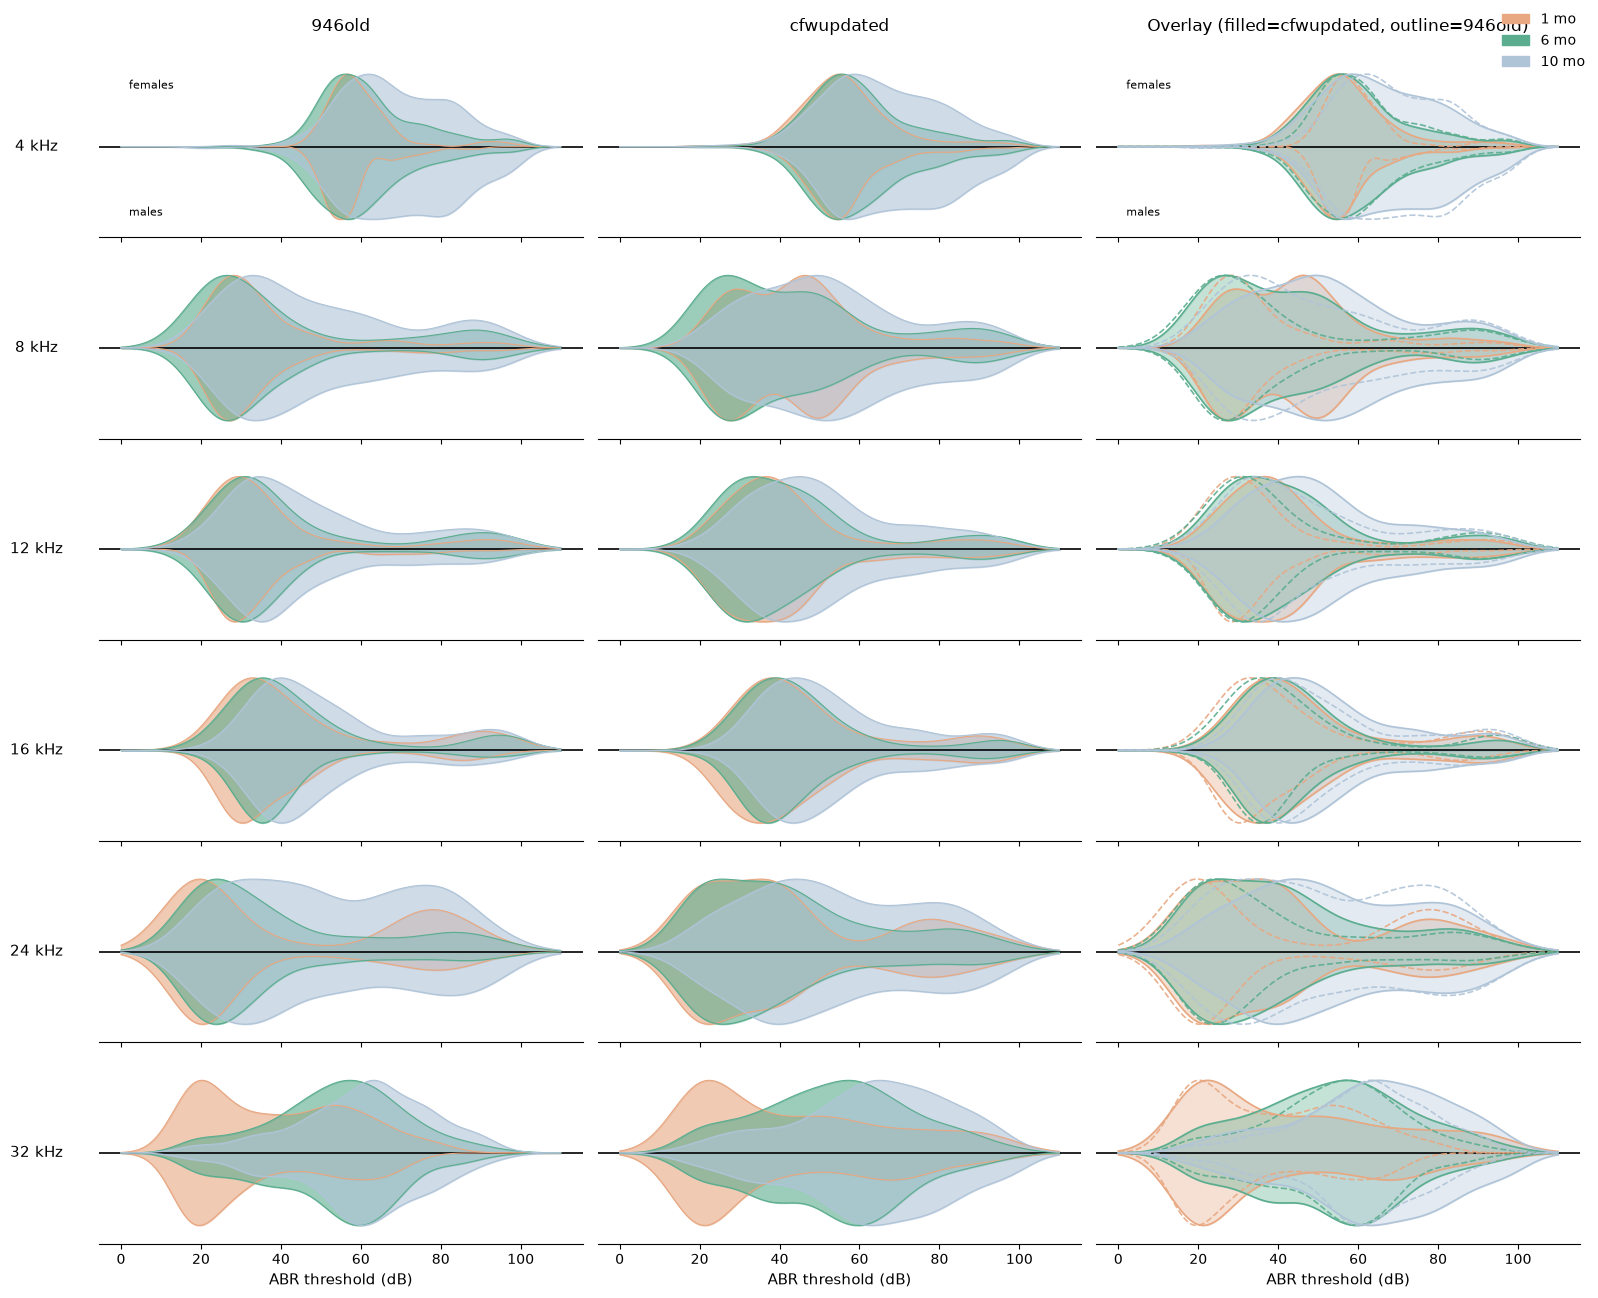

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

cfw = pd.read_csv("CFW.csv")
old946 = pd.read_csv("946idk.csv")

freqs = [4, 8, 12, 16, 24, 32]
ages = {
    '1 mo':  ['01mo_04_khz', '01mo_08_khz', '01mo_12_khz', '01mo_16_khz', '01mo_24_khz', '01mo_32_khz'],
    '6 mo':  ['06mo_04_khz', '06mo_08_khz', '06mo_12_khz', '06mo_16_khz', '06mo_24_khz', '06mo_32_khz'],
    '10 mo': ['10mo_04_khz', '10mo_08_khz', '10mo_12_khz', '10mo_16_khz', '10mo_24_khz', '10mo_32_khz'],
}
colors = {'1 mo': '#E8A882', '6 mo': '#5BAD8F', '10 mo': '#B0C4D8'}

x_range = np.linspace(0, 110, 300)


def get_values(df, col, sex=None):
    sub = df if sex is None else df[df['sex'] == sex]
    return pd.to_numeric(sub[col].replace('NR', np.nan), errors='coerce').dropna()


def norm_density(vals, bw=0.3):
    if len(vals) < 5:
        return None
    kde = gaussian_kde(vals, bw_method=bw)
    d = kde(x_range)
    return d / d.max()


# ── Figure: rows = frequencies, cols = [946old, cfwupdated, overlay] ──
fig, axes = plt.subplots(len(freqs), 3, figsize=(16, 13), sharex=True)
fig.subplots_adjust(hspace=0.15)

col_titles = ['946old', 'cfwupdated', 'Overlay (filled=cfwupdated, outline=946old)']

for row, freq_idx in enumerate(range(len(freqs))):

    # ---------- Columns 0 & 1: same sex-split ridge as before ----------
    for col_idx, (dataset, dataset_name) in enumerate([(old946, '946old'), (cfw, 'cfwupdated')]):
        ax = axes[row][col_idx]
        ax.axhline(0, color='black', linewidth=1.2)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)

        for age_label, col_list in ages.items():
            col = col_list[freq_idx]
            color = colors[age_label]
            for sex, sign in [('F', 1), ('M', -1)]:
                vals = get_values(dataset, col, sex=sex)
                density = norm_density(vals)
                if density is None:
                    continue
                density = density * 0.4 * sign
                ax.fill_between(x_range, 0, density, alpha=0.6, color=color)
                ax.plot(x_range, density, color=color, linewidth=0.8)

        ax.set_ylim(-0.5, 0.5)
        if col_idx == 0:
            ax.set_ylabel(f'{freqs[freq_idx]} kHz', rotation=0, labelpad=45, va='center', fontsize=11)
        if row == 0:
            ax.set_title(dataset_name, fontsize=12, pad=18)
            if col_idx == 0:
                ax.text(2, 0.32, 'females', fontsize=8)
                ax.text(2, -0.38, 'males', fontsize=8)

    # ---------- Column 2: Overlay, same up/down=sex convention kept ----------
    ax = axes[row][2]
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left']].set_visible(False)

    for age_label, col_list in ages.items():
        col = col_list[freq_idx]
        color = colors[age_label]

        for sex, sign in [('F', 1), ('M', -1)]:
            # cfwupdated: filled, solid outline
            vals_new = get_values(cfw, col, sex=sex)
            d_new = norm_density(vals_new)
            if d_new is not None:
                d_new = d_new * 0.4 * sign
                ax.fill_between(x_range, 0, d_new, alpha=0.35, color=color)
                ax.plot(x_range, d_new, color=color, linewidth=1.2, linestyle='-')

            # 946old: outline only, dashed, no fill
            vals_old = get_values(old946, col, sex=sex)
            d_old = norm_density(vals_old)
            if d_old is not None:
                d_old = d_old * 0.4 * sign
                ax.plot(x_range, d_old, color=color, linewidth=1.2, linestyle='--', alpha=0.9)

    ax.set_ylim(-0.5, 0.5)
    if row == 0:
        ax.set_title(col_titles[2], fontsize=12, pad=18)
        ax.text(2, 0.32, 'females', fontsize=8)
        ax.text(2, -0.38, 'males', fontsize=8)

# Shared legend + x-label
legend_patches = [plt.matplotlib.patches.Patch(color=colors[a], label=a) for a in ages]
for ax in axes[-1]:
    ax.set_xlabel('ABR threshold (dB)', fontsize=11)
fig.legend(handles=legend_patches, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("ridge_overlay.png", dpi=150, bbox_inches='tight')
plt.show()